# Generate Figures: in vitro High-Throughput Analysis

- Figures 2, 3, 4 
- S1A and B
- S2
- S3B-E

### Libraries and Analysis-Wide Variables

In [1]:
options(warn = -1)

suppressPackageStartupMessages({
  library(plyranges)
  library(tidyverse)
  library(rasilabRtemplates)
  library(ggpubr)
  library(RColorBrewer)
  library(Biostrings)
  library(cowplot)
})

wildtype_boxb <- "GGGCCCTGAAGAAGGGCCC"
wildtype_boxb_rc <- "GGGCCCTTCTTCAGGGCCC"
time_order=c("37_30min","37_1hr","37_2hr")
position_order=c("5","3")

### Read In Data

In [2]:
target_data <- list.files("../data/summary_stats_combined/", full.names = T, pattern = ".csv.gz") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    print()

# A tibble: 1,391,218 × 89
   sample_id barcode    insert umi_cou…¹ num_0_a num_0_g num_0_t num_0_c num_0_n
   <chr>     <chr>      <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 i79_p1    AAAAGACAGG TTGAG        186     186     186       0     185     186
 2 i79_p1    AAAAGACAGG GTGAT        127     126     127       0     127     127
 3 i79_p1    AAAAGACAGG AGTCA         62      62      62       0      62      62
 4 i79_p1    AAAAGACAGG GAAGT        109     109     109       0     107     109
 5 i79_p1    AAAAGACAGG ATTGA         90      89      90       0      90      90
 6 i79_p1    AAAAGACAGG CAAGC         49      49      49       0      48      49
 7 i79_p1    AAAAGACAGG GATAT         97      97      97       0      94      97
 8 i79_p1    AAAAGACAGG GTATT        144     144     144       0     144     144
 9 i79_p1    AAAAGACAGG TTAAG        104     104     104       0     103     104
10 i79_p1    AAAAGACAGG TGGCA         91      91      91       0      90      91
#

In [3]:
boxb_loop_data <- list.files("../data/boxb_stats_combined/", full.names = T, pattern = ".csv.gz") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    print()

# A tibble: 1,391,218 × 39
   sample_id barcode    insert umi_cou…¹ num_0_a num_0_g num_0_t num_0_c num_0_n
   <chr>     <chr>      <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 i79_p1    AAAAGACAGG TTGAG        186     186     186       0     186     186
 2 i79_p1    AAAAGACAGG GTGAT        127     127     127       0     127     127
 3 i79_p1    AAAAGACAGG AGTCA         62      62      62       0      62      62
 4 i79_p1    AAAAGACAGG GAAGT        109     109     109       0     109     109
 5 i79_p1    AAAAGACAGG ATTGA         90      90      90       0      90      90
 6 i79_p1    AAAAGACAGG CAAGC         49      49      49       0      49      49
 7 i79_p1    AAAAGACAGG GATAT         97      97      97       0      97      97
 8 i79_p1    AAAAGACAGG GTATT        144     144     144       0     144     144
 9 i79_p1    AAAAGACAGG TTAAG        104     104     104       0     104     104
10 i79_p1    AAAAGACAGG TGGCA         91      91      91       0      91      91
#

### Read in Annotations and Join

In [4]:
barcode_annotations <- read_csv("../annotations/barcode_annotations.csv", show_col_types = F) %>%
    select(-barcode) %>%
    rename(barcode = reverse_complement) %>%
    print()

sample_annotations <- read_csv("../annotations/sample_info.csv", show_col_types = F) %>%
    print()

hairpin_annotations <- read_tsv("../annotations/hairpin_annotations.tsv", show_col_types = F) %>%
    rename("insert" = "variable_region") %>%
    print()

target_data <- target_data %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(sample_annotations, by = "sample_id") %>%
    print()

loop_data <- boxb_loop_data %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(sample_annotations, by = "sample_id") %>%
    print()

# A tibble: 96 × 14
   barcode    oligo_name n_var…¹ varia…² varia…³ targe…⁴ targe…⁵ targe…⁶ targe…⁷
   <chr>      <chr>        <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 AAGACGCCCA spacer5_3…    1024      62      17      62      17       5      30
 2 CGCGGGACCG spacer3_3…    1024      42      17      42      17       3       0
 3 CGAAAAGAGC spacer5_3…    1024      62      17      62      17       5      30
 4 CCGCACCGCC spacer3_3…    1024      42      17      42      17       3       0
 5 CGAAACAGAA spacer5_2…    1024      60      17      60      17       5      28
 6 GGCGCACAGA spacer3_2…    1024      40      17      40      17       3       2
 7 CAACCAGCCA spacer5_2…    1024      60      17      60      17       5      28
 8 AGAAAGACCA spacer3_2…    1024      40      17      40      17       3       2
 9 AAAAGACAGG spacer5_2…    1024      58      17      58      17       5      26
10 CCACCGAGCC spacer3_2…    1024      38      17      38      17       3       4
# … with

### Generate Table of Wildtype Inserts

In [ ]:
wildtype_boxb_random_inserts <- barcode_annotations  %>%
  filter(str_detect(oligo_name, "boxb_random")) %>%
  distinct(variable_subpos)  %>%
  separate(variable_subpos, c("start", "end"), remove = F) %>%
  mutate(wt_insert = c("CCC","GGG","TTCA","TTCT","CCC","GGG")) %>%
  # mutate(wt_insert = str_sub(wt_seq, as.numeric(start), as.numeric(end)))  %>%
  select(variable_subpos, wt_insert, insert_type) %>%
  print()

wildtype_target_random_inserts <- barcode_annotations  %>%
  filter(str_detect(oligo_name, "target_random")) %>%
  distinct(variable_subpos)  %>%
  mutate(wt_insert = c("GAACA","AAGGG")) %>%
  print()


# A tibble: 6 × 3
  variable_subpos wt_insert insert_type
  <chr>           <chr>     <chr>      
1 1_3             CCC       stem       
2 4_6             GGG       stem       
3 7_10            TTCA      loop       
4 10_13           TTCT      loop       
5 14_16           CCC       stem       
6 17_19           GGG       stem       
# A tibble: 2 × 2
  variable_subpos wt_insert
  <chr>           <chr>    
1 5               GAACA    
2 3               AAGGG    


### Table: Mean Loop Editing per Concentration
- Figure 2B

In [6]:
options(repr.plot.width = 5, repr.plot.height = 4)
legend_labels=c("lambdaN"="λN-TadA","tada_only"="TadA")

mean_loop_editing_per_concentration <- loop_data  %>%
  filter(variable_type=="target", g_depleted=="no",sample_id %in% c("i79_p8","i79_p7","i79_p9","i79_p2","i79_p3","i79_p4")) %>%
  group_by(sample_id,barcode)%>%
  mutate(across(matches("num_._C"), ~ round(sum(.x) / sum(umi_counts), 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_C) %>%
  select(sample_id, sample_name, variable_subpos, matches("fraction_"),tada_type,tada_conc) %>%
  group_by(tada_type,tada_conc) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  .groups = "drop")%>%
  print()

write_tsv(mean_loop_editing_per_concentration,"../tables/mean_loop_editing_per_concentration.tsv")

Adding missing grouping variables: `barcode`


# A tibble: 6 × 4
  tada_type tada_conc   mean        se
  <chr>     <chr>      <dbl>     <dbl>
1 lambdaN   125nM     0.0757 0.0000840
2 lambdaN   250nM     0.0789 0.0000685
3 lambdaN   500nM     0.0987 0.0000456
4 tada_only 125nM     0.0963 0.0000903
5 tada_only 250nM     0.150  0.0000623
6 tada_only 500nM     0.487  0.0000421


### Table: Mean Editing for Recorder at Each Position in Reporter
- Direct LN fusion only
- Data for Figure 2C


In [7]:
options(repr.plot.width = 8, repr.plot.height = 5)
raw_data <- target_data  %>%
  filter(variable_type=="target", g_depleted=="no",sample_id %in% c("i79_p3")) %>%
  mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c)%>%
  print()


mean_editing_recorder_position<- raw_data %>%
  select(target_dist,target_pos_to_boxb, matches("fraction_")) %>%
  group_by(target_pos_to_boxb,target_dist) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  n=n(),
  .groups = "drop")%>%
  mutate(absolute_dist=case_when(
    target_pos_to_boxb=="5" ~ 30-target_dist,
    target_pos_to_boxb=="3" ~ target_dist
  ))%>%
  print()

  write_tsv(mean_editing_recorder_position,"../tables/mean_editing_recorder_position.tsv")

# A tibble: 65,536 × 121
   sample_id barcode    insert umi_cou…¹ num_0_a num_0_g num_0_t num_0_c num_0_n
   <chr>     <chr>      <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 i79_p3    AAAAGACAGG TGGGA        201     201     201       0     163     201
 2 i79_p3    AAAAGACAGG AGGTG        206     206     206       0     130     206
 3 i79_p3    AAAAGACAGG TGCCC         58      58      58       0      43      58
 4 i79_p3    AAAAGACAGG TAGGC        118     118     118       0     103     118
 5 i79_p3    AAAAGACAGG GACAC         61      61      61       0      26      61
 6 i79_p3    AAAAGACAGG GGCCG        117     117     117       0     101     117
 7 i79_p3    AAAAGACAGG CTGGG        184     184     184       0     158     184
 8 i79_p3    AAAAGACAGG TGTCG        174     173     174       0     159     174
 9 i79_p3    AAAAGACAGG GCGGA        120     120     120       0     104     120
10 i79_p3    AAAAGACAGG CCTTT         67      66      67       0      49      67
# …

### Table: Mean Editing for Each A in Recorder
- For boxB and recorder sequence constant
- Mean across all reporter spacing configurations
- Figure 2D
- Figure S1A
- Figure S3B

In [8]:
options(repr.plot.width = 6, repr.plot.height = 3)
position_labs=c("7"="UAG",
"6"="GAA",
"5"="AAU",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU",
"1"= "UAA",
"0"= "AAU"
)
position_order=c("7","6","5","4","3","2","1","0")


individual_a_editing_context_constant <- target_data  %>%
  filter(variable_type=="boxb", g_depleted=="no", sample_id %in% c("i79_p3","i79_p2","i79_p4","i79_p10","i79_p20")) %>%
  inner_join(wildtype_boxb_random_inserts, by = c("variable_subpos", "insert" = "wt_insert")) %>%
  mutate(across(matches("pos_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}")) %>%
  select(tada_type,tada_conc,target_dist, matches("fraction_")) %>%
  group_by(tada_type,tada_conc)%>%
  summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
  across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
  across(starts_with("fraction_"),~n(),.names="n_{col}"),
  .groups = "drop")%>%
    pivot_longer(
    cols = c(starts_with("mean_"),starts_with("se_"),starts_with("n_")), 
    names_to = c(".value", "position"),
    names_pattern = "(mean|se|n)_fraction_pos_(\\d+)_c"
  )%>%
  group_by(tada_conc,tada_type)%>%
  mutate(scaled_mean = rank(mean))%>%
  print()

write_tsv(individual_a_editing_context_constant,"../tables/individual_a_editing_context_constant.tsv")

# A tibble: 40 × 7
# Groups:   tada_conc, tada_type [5]
   tada_type tada_conc position   mean      se     n scaled_mean
   <chr>     <chr>     <chr>     <dbl>   <dbl> <int>       <dbl>
 1 gfpnb     250nM     0        0.0732 0.0105     24           3
 2 gfpnb     250nM     1        0.143  0.0182     24           6
 3 gfpnb     250nM     2        0.0360 0.00629    24           1
 4 gfpnb     250nM     3        0.0723 0.00967    24           2
 5 gfpnb     250nM     4        0.240  0.0222     24           7
 6 gfpnb     250nM     5        0.0988 0.0100     24           4
 7 gfpnb     250nM     6        0.125  0.0117     24           5
 8 gfpnb     250nM     7        0.349  0.0228     24           8
 9 lambdaN   125nM     0        0.0292 0.0120     24           6
10 lambdaN   125nM     1        0.0259 0.00488    24           5
# … with 30 more rows


### Mean Editing for Individual As in Variable Sequence Context
- Data for Figure 2E

In [9]:
context_data <- target_data %>%
    filter(sample_id=="i79_p3",variable_type=="target",target_pos_to_boxb=="5") %>%
    mutate(across(matches("pos_._c"),~.x/umi_counts,.names="fraction_{col}"))%>%
    select(insert,variable_subpos,umi_counts,starts_with("fraction_"))%>%
    filter(umi_counts>50)%>%
    group_by(insert,variable_subpos)%>%
    summarize(across(starts_with("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    .groups="drop")%>%
    print()

five_prime_variable <- context_data %>%
    filter(variable_subpos=="5")%>%
    select(insert,variable_subpos,mean_fraction_pos_7_c,mean_fraction_pos_4_c)%>%
    mutate(
        fiveprime_7=str_sub(insert,5,5),
        threeprime_7=str_sub(insert,4,4),
        fiveprime_4=str_sub(insert,2,2),
        threeprime_4=str_sub(insert,1,1),
        across(matches("prime"),~case_when(
        .x %in% c("T","C") ~ "R",
        .x=="A" ~ "U",
        .x=="G" ~ "C"),
        .names="{col}_id")
    ) %>%
    select(starts_with("mean"),ends_with("_id"))%>%
    pivot_longer(
        cols=everything(),
        names_to = c(".value", "position"),
        names_pattern = "(.*)_(\\d+)" 
    )%>%
    group_by(position,fiveprime,threeprime)%>%
    summarize(mean=mean(mean_fraction_pos))

individual_a_editing_context_variable <- context_data %>%
    filter(variable_subpos=="3")%>%
    select(insert,variable_subpos,mean_fraction_pos_3_c,mean_fraction_pos_2_c)%>%
    mutate(
        fiveprime_3=str_sub(insert,5,5),
        threeprime_3=str_sub(insert,4,4),
        fiveprime_2=str_sub(insert,3,3),
        threeprime_2=str_sub(insert,2,2),
        across(matches("prime"),~case_when(
        .x %in% c("T","C") ~ "R",
        .x=="A" ~ "U",
        .x=="G" ~ "C"),
        .names="{col}_id")
    ) %>%
    select(starts_with("mean"),ends_with("_id"))%>%
    pivot_longer(
        cols=everything(),
        names_to = c(".value", "position"),
        names_pattern = "(.*)_(\\d+)" 
    )%>%
    group_by(position,fiveprime,threeprime)%>%
    summarize(mean=mean(mean_fraction_pos))%>%
    bind_rows(five_prime_variable)%>%
    print()

write_tsv(individual_a_editing_context_variable,"../tables/individual_a_editing_context_variable.tsv")

# A tibble: 1,964 × 18
   insert variable_sub…¹ mean_…² mean_…³ mean_…⁴ mean_…⁵ mean_…⁶ mean_…⁷ mean_…⁸
   <chr>  <chr>            <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 AAAAA  3               0.0104  0.985   0.988    0.990  0.0177 0.00624  0.0114
 2 AAAAC  3               0.109   0.364   0.436    0.127  0.364  0.109    0.2   
 3 AAAAC  5               0.0490  0.0782  0.0390   0.272  0.136  0.0583   0.223 
 4 AAAAG  3               0.0908  0.381   0.373    0.161  0.326  0.115    0.171 
 5 AAAAG  5               0.0513  0.131   0.0494   0.336  0.352  0.103    0.294 
 6 AAAAT  3               0.0577  0.261   0.319    0.124  0.260  0.144    0.221 
 7 AAAAT  5               0.0357  0.102   0        0.183  0.203  0.0371   0.130 
 8 AAACA  5               0.0471  0.126   0.0665   0.314  0.294  0.123    0.155 
 9 AAACC  5               0.0754  0.180   0.0294   0.404  0.345  0.149    0.216 
10 AAACG  3               0.0901  0.366   0.471    0.154  0.275  0.147    0.173 
# … w

`summarise()` has grouped output by 'position', 'fiveprime'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'position', 'fiveprime'. You can override
using the `.groups` argument.


# A tibble: 36 × 4
# Groups:   position, fiveprime [12]
   position fiveprime threeprime   mean
   <chr>    <chr>     <chr>       <dbl>
 1 2        C         C          0.0106
 2 2        C         R          0.0208
 3 2        C         U          0.0442
 4 2        R         C          0.0209
 5 2        R         R          0.0327
 6 2        R         U          0.0620
 7 2        U         C          0.132 
 8 2        U         R          0.186 
 9 2        U         U          0.327 
10 3        C         C          0.0247
# … with 26 more rows


### Edits per Loop Variant (for GNRNA Comparison Violin Plots)
- Data for Figure 3B, Figure 4D

In [10]:
stats_per_boxb_insert <- target_data %>%
    filter(variable_type=="boxb", sample_id %in% c("i79_p3","i79_p10","i79_p20","i79_p3","i79_p4","i79_p8")) %>%
    filter(umi_counts>200)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(tada_type,tada_conc,variable_subpos,insert, fraction_edited) %>%
    group_by(tada_type,variable_subpos,insert)%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
print()

loop_data_tmp <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("7_10"))%>%
    mutate(boxb_7=str_sub(insert,4,4),
        boxb_8=str_sub(insert,3,3),
        boxb_9=str_sub(insert,2,2),
        boxb_10=str_sub(insert,1,1),
        boxb_11="C",
        boxb_12="T",
        boxb_13="T")%>%
    print()

editing_per_loop_variant <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("10_13"))%>%
    mutate(boxb_7="A",
        boxb_8="C",
        boxb_9="T",
        boxb_10=str_sub(insert,4,4),
        boxb_11=str_sub(insert,3,3),
        boxb_12=str_sub(insert,2,2),
        boxb_13=str_sub(insert,1,1))%>%
    bind_rows(loop_data_tmp)%>%
    mutate(gnra=boxb_8=="C"&(boxb_10=="T"|boxb_10=="C")&boxb_12=="T",
        boxb_8_rc=case_when(
        boxb_8=="A" ~ "T",
        boxb_8=="C" ~ "G",
        boxb_8=="G" ~ "C",
        boxb_8=="T" ~ "A"
        ), boxb_10_rc=case_when(
        boxb_10=="A" ~ "T",
        boxb_10=="C" ~ "G",
        boxb_10=="G" ~ "C",
        boxb_10=="T" ~ "A"
        ), boxb_12_rc=case_when(
        boxb_12=="A" ~ "T",
        boxb_12=="C" ~ "G",
        boxb_12=="G" ~ "C",
        boxb_12=="T" ~ "A"
        ))%>%
        filter(boxb_7=="A"&boxb_13=="T")%>%
    print()

write_tsv(editing_per_loop_variant,"../tables/editing_per_loop_variant.tsv")

# A tibble: 10,741 × 7
# Groups:   tada_type, variable_subpos, insert [2,041]
   tada_type tada_conc variable_subpos insert fraction_edited free_ene…¹ hairpin
   <chr>     <chr>     <chr>           <chr>            <dbl>      <dbl> <chr>  
 1 pAG       250nM     1_3             GAT              0.555       -5.2 ATCCCC…
 2 pAG       250nM     1_3             CTC              0.725       -8.9 GAGCCC…
 3 pAG       250nM     1_3             TTA              0.453       -5.6 TAACCC…
 4 pAG       250nM     1_3             ATC              0.574       -5   GATCCC…
 5 pAG       250nM     1_3             TGA              0.419       -5.6 TCACCC…
 6 pAG       250nM     1_3             CGG              0.650       -9   CCGCCC…
 7 pAG       250nM     1_3             CAC              0.727       -8.7 GTGCCC…
 8 pAG       250nM     1_3             GCA              0.457       -6.3 TGCCCC…
 9 pAG       250nM     1_3             GAC              0.510       -5.2 GTCCCC…
10 pAG       250nM     1_3     

### Mean Edits per Loop Variant (for heatmaps)
- Data for 3C and 3D
- 4E
- S2B
- S2C
- S3C

In [11]:
enzyme_order=c("tada_only","lambdaN","gfpnb","pAG")
facet_labels <- c("TadA Alone","TadA-LambdaN","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order


stats_per_boxb_insert <- target_data %>%
    filter(variable_type=="boxb", sample_id %in% c("i79_p3","i79_p10","i79_p20","i79_p2","i79_p8","i79_p10","i79_p20")) %>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(tada_type,tada_conc,variable_subpos,insert, fraction_edited) %>%
    group_by(tada_type,tada_conc,variable_subpos,insert)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    .groups = "drop")%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
print()

loop_data_tmp <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("7_10"))%>%
    mutate(boxb_7=str_sub(insert,4,4),
        boxb_8=str_sub(insert,3,3),
        boxb_9=str_sub(insert,2,2),
        boxb_10=str_sub(insert,1,1),
        boxb_11="C",
        boxb_12="T",
        boxb_13="T")%>%
    print()

mean_editing_per_loop_variant <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("10_13"))%>%
    mutate(boxb_7="A",
        boxb_8="C",
        boxb_9="T",
        boxb_10=str_sub(insert,4,4),
        boxb_11=str_sub(insert,3,3),
        boxb_12=str_sub(insert,2,2),
        boxb_13=str_sub(insert,1,1))%>%
    bind_rows(loop_data_tmp)%>%
    mutate(gnra=boxb_8=="C"&(boxb_10=="T"|boxb_10=="C")&boxb_12=="T",
        boxb_8_rc=case_when(
        boxb_8=="A" ~ "U",
        boxb_8=="C" ~ "G",
        boxb_8=="G" ~ "C",
        boxb_8=="T" ~ "A"
        ), boxb_10_rc=case_when(
        boxb_10=="A" ~ "U",
        boxb_10=="C" ~ "G",
        boxb_10=="G" ~ "C",
        boxb_10=="T" ~ "A"
        ), boxb_12_rc=case_when(
        boxb_12=="A" ~ "U",
        boxb_12=="C" ~ "G",
        boxb_12=="G" ~ "C",
        boxb_12=="T" ~ "A"
        ),boxb_7_rc=case_when(
        boxb_7=="A" ~ "U",
        boxb_7=="C" ~ "G",
        boxb_7=="G" ~ "C",
        boxb_7=="T" ~ "A"
        ), boxb_13_rc=case_when(
        boxb_13=="A" ~ "U",
        boxb_13=="C" ~ "G",
        boxb_13=="G" ~ "C",
        boxb_13=="T" ~ "A")
    )%>%
    print()

write_tsv(mean_editing_per_loop_variant,"../tables/mean_editing_per_loop_variant.tsv")

# A tibble: 3,841 × 8
   tada_type tada_conc variable_subpos insert mean_fra…¹ se_fr…² free_…³ hairpin
   <chr>     <chr>     <chr>           <chr>       <dbl>   <dbl>   <dbl> <chr>  
 1 gfpnb     250nM     1_3             AAA         0.345  0.0328    -5   TTTCCC…
 2 gfpnb     250nM     1_3             AAC         0.365  0.0514    -5   GTTCCC…
 3 gfpnb     250nM     1_3             AAG         0.209  0.0124    -5   CTTCCC…
 4 gfpnb     250nM     1_3             AAT         0.295  0.0361    -5   ATTCCC…
 5 gfpnb     250nM     1_3             ACA         0.402  0.0386    -5   TGTCCC…
 6 gfpnb     250nM     1_3             ACC         0.440  0.0414    -8.2 GGTCCC…
 7 gfpnb     250nM     1_3             ACG         0.340  0.0241    -5.2 CGTCCC…
 8 gfpnb     250nM     1_3             ACT         0.293  0.0252    -5.1 AGTCCC…
 9 gfpnb     250nM     1_3             AGA         0.306  0.0377    -5   TCTCCC…
10 gfpnb     250nM     1_3             AGC         0.346  0.0338    -5   GCTCCC…
# … wi

### Mean Editing per Stem Variants
- Data for 3I and 3J
- 4F
- S2D

In [12]:
mean_editing_per_stem_variant <- target_data %>%
    filter(variable_type=="boxb", sample_id %in% c("i79_p3","i79_p5","i79_p6","i79_p10","i79_p20","i79_p2","i79_p4","i79_p8","i79_p7")) %>%
    filter(variable_subpos %in% c("1_3","4_6","14_16","17_19"))%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(tada_type,tada_conc,variable_subpos,insert, condition, fraction_edited) %>%
    group_by(tada_type,tada_conc,variable_subpos,insert,condition)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    .groups = "drop")%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
    arrange(free_energy)%>%
    group_by(tada_type,tada_conc,condition)%>%
    mutate(energy_bins=ntile(row_number(),5))%>%
print()

write_tsv(mean_editing_per_stem_variant,"../tables/mean_editing_per_stem_variant.tsv")

# A tibble: 2,306 × 10
# Groups:   tada_type, tada_conc, condition [9]
   tada_type tada_conc variable…¹ insert condi…² mean_…³ se_fr…⁴ free_…⁵ hairpin
   <chr>     <chr>     <chr>      <chr>  <chr>     <dbl>   <dbl>   <dbl> <chr>  
 1 gfpnb     250nM     1_3        CCC    37_2hr    0.593  0.0491   -14.5 GGGCCC…
 2 gfpnb     250nM     14_16      CCC    37_2hr    0.442  0.0538   -14.5 GGGCCC…
 3 gfpnb     250nM     17_19      GGG    37_2hr    0.590  0.0414   -14.5 GGGCCC…
 4 gfpnb     250nM     4_6        GGG    37_2hr    0.595  0.0521   -14.5 GGGCCC…
 5 lambdaN   125nM     1_3        CCC    37_2hr    0.229  0.0517   -14.5 GGGCCC…
 6 lambdaN   125nM     14_16      CCC    37_2hr    0.118  0.0200   -14.5 GGGCCC…
 7 lambdaN   125nM     17_19      GGG    37_2hr    0.200  0.0292   -14.5 GGGCCC…
 8 lambdaN   125nM     4_6        GGG    37_2hr    0.177  0.0279   -14.5 GGGCCC…
 9 lambdaN   250nM     1_3        CCC    37_1hr    0.296  0.0570   -14.5 GGGCCC…
10 lambdaN   250nM     1_3        CCC 

### Mean Editing for Wildtype BoxB in Different Recruitments
- Figure 4C

In [13]:
enzyme_order=c("lambdaN","gfpnb","pAG")
facet_labels <- c("TadA-N","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order

boxb_plot_data <- loop_data  %>%
  filter(variable_type=="target", g_depleted=="no",sample_id %in% c("i79_p10","i79_p3","i79_p20")) %>%
  mutate(across(matches("num_._C"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_C) %>%
  select(sample_id, sample_name, variable_subpos, matches("fraction_"),tada_type,tada_conc) %>%
  group_by(tada_type) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  .groups = "drop")%>%
  mutate(data_type="boxb")%>%
  print()

mean_editing_per_recruitment_type <- target_data  %>%
  filter(variable_type=="target", g_depleted=="no",sample_id %in% c("i79_p10","i79_p3","i79_p20")) %>%
  inner_join(wildtype_target_random_inserts, by = c("variable_subpos", "insert" = "wt_insert")) %>%
  mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c) %>%
  select(sample_id, sample_name, variable_subpos, matches("fraction_"),tada_type,tada_conc) %>%
  group_by(tada_type) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  .groups = "drop")%>%
  mutate(data_type="target")%>%
  bind_rows(boxb_plot_data)%>%
  print()

  write_tsv(mean_editing_per_recruitment_type,"../tables/mean_editing_per_recruitment_type.tsv")

# A tibble: 3 × 4
  tada_type   mean       se data_type
  <chr>      <dbl>    <dbl> <chr>    
1 gfpnb     0.0991 0.000257 boxb     
2 lambdaN   0.120  0.000289 boxb     
3 pAG       0.0976 0.000282 boxb     
# A tibble: 6 × 4
  tada_type   mean       se data_type
  <chr>      <dbl>    <dbl> <chr>    
1 gfpnb     0.678  0.0155   target   
2 lambdaN   0.422  0.0162   target   
3 pAG       0.711  0.0132   target   
4 gfpnb     0.0991 0.000257 boxb     
5 lambdaN   0.120  0.000289 boxb     
6 pAG       0.0976 0.000282 boxb     


### Wide Table of BoxB Variants for Correlation Across Conditions

- Figures S3E and S3D

In [ ]:
mean_editing_per_boxb_variants_wide <- target_data %>%
    filter(variable_type=="boxb") %>%
    filter(umi_counts>100)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(sample_id,variable_subpos,insert,fraction_edited,tada_type) %>%
    group_by(sample_id,variable_subpos,insert,tada_type)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
        across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
        .groups = "drop")%>%
    select(sample_id,variable_subpos,insert,mean_fraction_edited)%>%
    pivot_wider(names_from=sample_id,values_from = mean_fraction_edited)%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
    print()

write_tsv(mean_editing_per_boxb_variants_wide,"../tables/mean_editing_per_boxb_variants_wide.tsv")

# A tibble: 661 × 24
   variable_sub…¹ insert  i79_p1 i79_p10 i79_p11 i79_p12 i79_p13 i79_p14 i79_p15
   <chr>          <chr>    <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 1_3            AAA    0.00289   0.344  0.107   0.0350  0.0772   0.605   0.270
 2 1_3            AAC    0.00302   0.414  0.113   0.0312  0.0950   0.660   0.318
 3 1_3            AAG    0.00300   0.190  0.0423  0.0120  0.0360   0.432   0.135
 4 1_3            AAT    0.00209   0.261  0.0827  0.0296  0.0746   0.431   0.210
 5 1_3            ACA    0.00327   0.427  0.149   0.0436  0.113    0.690   0.367
 6 1_3            ACC    0.00615   0.508  0.186   0.0676  0.160    0.710   0.386
 7 1_3            ACG    0.00308   0.388  0.120   0.0351  0.0884   0.626   0.288
 8 1_3            ACT    0.00350   0.259  0.0908  0.0244  0.0703   0.450   0.215
 9 1_3            AGA    0.00258   0.309  0.0862  0.0198  0.0773   0.560   0.235
10 1_3            AGC    0.00567   0.399  0.124   0.0350  0.104    0.634   0.293
# … wit

### Individual As in Variable Context, for As with One Variable Flanking Base
- S1B

In [21]:
context_data <- target_data %>%
    filter(sample_id=="i79_p3",variable_type=="target",target_pos_to_boxb=="5") %>%
    mutate(across(matches("pos_._c"),~.x/umi_counts,.names="fraction_{col}"))%>%
    select(insert,variable_subpos,umi_counts,starts_with("fraction_"))%>%
    filter(umi_counts>50)%>%
    group_by(insert,variable_subpos)%>%
    summarize(across(starts_with("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    .groups="drop")%>%
    print()

position_labs_single_flank=c("6"="GAA",
"5"= "AAU",
"1"= "UAA",
"0"= "AAU"
)
position_order_single_flank=c("6","5","1","0")

five_prime_variable <- context_data %>%
    filter(variable_subpos=="5")%>%
    select(insert,variable_subpos,mean_fraction_pos_6_c,mean_fraction_pos_5_c)%>%
    mutate(
        fiveprime_6=str_sub(insert,4,4),
        threeprime_6="T",
        fiveprime_5="T",
        threeprime_5=str_sub(insert,3,3),
        across(matches("prime"),~case_when(
        .x %in% c("T","C") ~ "R",
        .x=="A" ~ "U",
        .x=="G" ~ "C"),
        .names="{col}_id")
    ) %>%
    select(starts_with("mean"),ends_with("_id"))%>%
    pivot_longer(
        cols=everything(),
        names_to = c(".value", "position"),
        names_pattern = "(.*)_(\\d+)" 
    )%>%
    group_by(position,fiveprime,threeprime)%>%
    summarize(mean=mean(mean_fraction_pos))

mean_edits_single_flanking_context_variable <- context_data %>%
    select(insert,variable_subpos,mean_fraction_pos_1_c,mean_fraction_pos_0_c)%>%
    mutate(
        fiveprime_1=str_sub(insert,2,2),
        threeprime_1="T",
        fiveprime_0="T",
        threeprime_0=str_sub(insert,1,1),
        across(matches("prime"),~case_when(
        .x %in% c("T","C") ~ "R",
        .x=="A" ~ "U",
        .x=="G" ~ "C"),
        .names="{col}_id")
    ) %>%
    select(starts_with("mean"),ends_with("_id"))%>%
    pivot_longer(
        cols=everything(),
        names_to = c(".value", "position"),
        names_pattern = "(.*)_(\\d+)" 
    )%>%
    group_by(position,fiveprime,threeprime)%>%
    summarize(mean=mean(mean_fraction_pos))%>%
    bind_rows(five_prime_variable)%>%
    print()

write_tsv(mean_edits_single_flanking_context_variable,"../tables/mean_edits_single_flanking_context_variable.tsv")

# A tibble: 1,964 × 18
   insert variable_sub…¹ mean_…² mean_…³ mean_…⁴ mean_…⁵ mean_…⁶ mean_…⁷ mean_…⁸
   <chr>  <chr>            <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 AAAAA  3               0.0104  0.985   0.988    0.990  0.0177 0.00624  0.0114
 2 AAAAC  3               0.109   0.364   0.436    0.127  0.364  0.109    0.2   
 3 AAAAC  5               0.0490  0.0782  0.0390   0.272  0.136  0.0583   0.223 
 4 AAAAG  3               0.0908  0.381   0.373    0.161  0.326  0.115    0.171 
 5 AAAAG  5               0.0513  0.131   0.0494   0.336  0.352  0.103    0.294 
 6 AAAAT  3               0.0577  0.261   0.319    0.124  0.260  0.144    0.221 
 7 AAAAT  5               0.0357  0.102   0        0.183  0.203  0.0371   0.130 
 8 AAACA  5               0.0471  0.126   0.0665   0.314  0.294  0.123    0.155 
 9 AAACC  5               0.0754  0.180   0.0294   0.404  0.345  0.149    0.216 
10 AAACG  3               0.0901  0.366   0.471    0.154  0.275  0.147    0.173 
# … w

`summarise()` has grouped output by 'position', 'fiveprime'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'position', 'fiveprime'. You can override
using the `.groups` argument.


# A tibble: 12 × 4
# Groups:   position, fiveprime [8]
   position fiveprime threeprime   mean
   <chr>    <chr>     <chr>       <dbl>
 1 0        R         C          0.0300
 2 0        R         R          0.0295
 3 0        R         U          0.0389
 4 1        C         R          0.0640
 5 1        R         R          0.0558
 6 1        U         R          0.144 
 7 5        R         C          0.0228
 8 5        R         R          0.0295
 9 5        R         U          0.0505
10 6        C         R          0.0196
11 6        R         R          0.0440
12 6        U         R          0.214 


## Figure 2

### Figure 2B

In [ ]:
  mean_editing_per_concentration %>% write_tsv("../tables/fig_2b_1_data.tsv")
  
  fig2b_1 <- mean_editing_per_concentration  %>%
  ggplot(aes(x = tada_conc, y = mean*100, color=tada_type)) +  
  geom_point(size=1) +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 100)) +
  scale_x_discrete(labels=c("100","250","500"))+
  scale_color_discrete(labels=legend_labels)+
      theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      legend.position = "none"
    )+
    labs(x = "Enzyme Concentration (nM)", y = "Percent Edited: Recorder",color="TadA Type")
  
  mean_loop_editing_per_concentration %>% write_tsv("../tables/fig_2b_2_data.tsv")

  fig2b_2 <- mean_loop_editing_per_concentration  %>%
  ggplot(aes(x = tada_conc, y = mean*100, color=tada_type)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=c("100","250","500"))+
  scale_y_continuous(limits = c(0, 100)) +
  scale_color_discrete(labels=legend_labels)+
      theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      legend.position = "none"
    )+
    labs(x = "Enzyme Concentration (nM)", y = "Percent Edited: boxB Loop",color="TadA Type")

shared_legend <- get_legend(
  fig2b_1 + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

plots_combined <- plot_grid(
  fig2b_1, fig2b_2,
  nrow = 1,
  align = "hv"
)

final_plot <- plot_grid(
  plots_combined, shared_legend,
  rel_widths = c(1, 0.25)  # Adjust as needed
)

# Display the final plot
print(plots_combined)
ggsave("../figures/figure_2b.pdf", height=2, width=3)

### Figure 2C

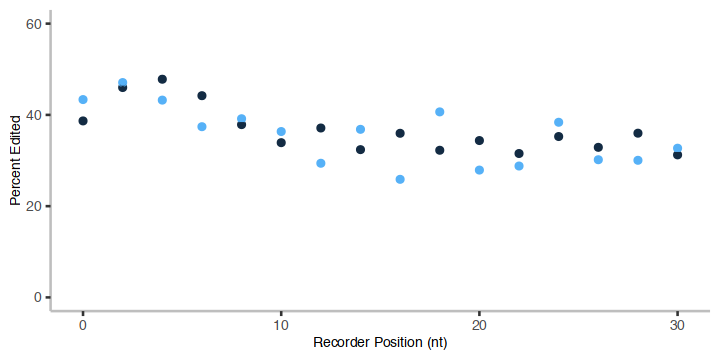

In [ ]:
mean_editing_recorder_position  %>% write_tsv("../tables/fig_2c_data.tsv")

mean_editing_recorder_position  %>%
  ggplot(aes(x = absolute_dist, y = mean*100,color=target_pos_to_boxb)) + 
  # facet_wrap(~target_pos_to_boxb,ncol=1)+
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 60)) +
  guides(color="none")+
  theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey")
    )+
    labs(x = "Recorder Position (nt)", y = "Percent Edited")

ggsave("../figures/boxb_distance.pdf",height = 1.25,width = 4)

### Figure 2D

In [ ]:
position_labs=c("7"="UAG",
"6"="GAA",
"5"="AAU",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU",
"1"= "UAA",
"0"= "AAU"
)
position_order=c("7","6","5","4","3","2","1","0")

individual_a_editing_context_constant  %>%
  filter(tada_conc=="250nM",tada_type=="lambdaN")%>%
  write_tsv("../tables/fig_2d_data.tsv")

figure_2d<- individual_a_editing_context_constant  %>%
  filter(tada_conc=="250nM",tada_type=="lambdaN")%>%
  ggplot(aes(x = factor(position,level=position_order), y = mean*100,color=as_factor(mean))) +  
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=position_labs)+
  scale_y_continuous(limits = c(0, 25)) +
  scale_color_brewer(palette = "RdBu",direction= -1)+
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "Recorder Position Context", y = "Percent Edited")

# ggsave("../figures/context_constant.pdf",height = 2,width = 3)

### Figure 2E

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 3)
subset_position_labs=c("7"="UAG",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU"
)
subset_position_order=c("7","4","3","2")

figure_2e <- individual_a_editing_context_variable %>%
    ggplot(aes(y=fiveprime,x=threeprime,fill=mean*100))+
    facet_wrap(~factor(position,level=subset_position_order),labeller=as_labeller(subset_position_labs),nrow=1)+
    geom_tile()+
    scale_fill_gradient(
        name="Percent\nEdited",
        low = "grey93", high = "black",
        limits = c(0, 48),
        guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
    theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8,hjust=0.5),
        legend.text = element_text(size = 8),
        strip.text.x=element_text(size=8)
        )+
        labs(y = "5' Flanking\n Base", x = "3' Flanking Base"
         )

# ggsave("../figures/context_variable.pdf",height = 1.2,width = 3.5)

### Construct Figure 2D and E together

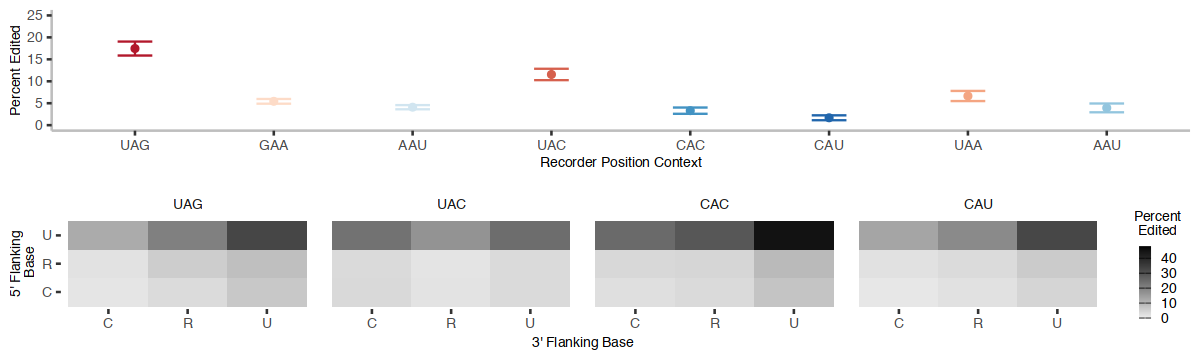

In [23]:
plot_grid(
  figure_2d, figure_2e,
  ncol = 1,
  align = "hv")

ggsave("../figures/figure_2d_2e.pdf",height = 2.25,width = 3.25)

## Figure 3

### 3B

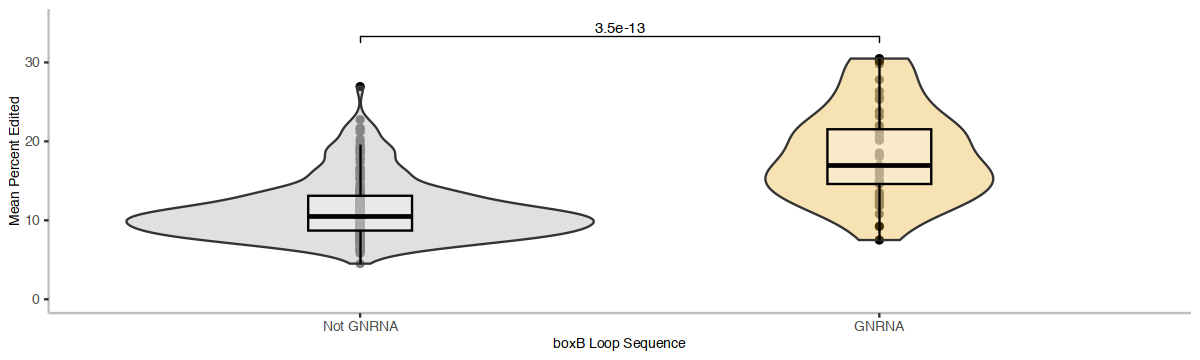

In [ ]:
editing_per_loop_variant %>%
    filter(tada_type=="lambdaN",tada_conc=="250nM")%>%
    write_tsv("../tables/fig_3b_data.tsv")


editing_per_loop_variant %>%
    filter(tada_type=="lambdaN",tada_conc=="250nM")%>%
    ggplot(aes(x=gnra,y=fraction_edited*100,fill=gnra))+
        geom_point(color="grey50")+
        geom_point(data=editing_per_loop_variant%>%filter(gnra=="FALSE",boxb_7=="A"&boxb_13=="T",fraction_edited>.25,tada_type=="lambdaN",tada_conc=="250nM"),color="black")+
        geom_point(data=editing_per_loop_variant%>%filter(gnra=="TRUE",boxb_7=="A"&boxb_13=="T",fraction_edited>.30,tada_type=="lambdaN",tada_conc=="250nM"),color="black")+
        geom_point(data=editing_per_loop_variant%>%filter(gnra=="TRUE",boxb_7=="A"&boxb_13=="T",fraction_edited<.10,tada_type=="lambdaN",tada_conc=="250nM"),color="black")+
        # annotate("label",
        #    x = c(1.35, 2.35,2.35,2.35,2.35), 
        #    y = c(27, 32.3,29.1,8.5,5.3), 
        #    label = c("UGAGA", "GGAGA","GAAGA","GAAUA","GAACA"),  
        #    size = 3,
        #    label.size = 0)+
        geom_violin(alpha=0.3)+
        geom_boxplot(width = 0.2, fill = "white", alpha=0.3, color = "black", outlier.shape = NA) +
        theme_classic()+
        scale_fill_manual(values=cbPalette,guide="none")+
        labs(x = "boxB Loop Sequence", y = "Mean Percent Edited",
         )+
        scale_x_discrete(labels=c("Not GNRNA","GNRNA"))+
        scale_y_continuous(limits=c(0,35))+
        stat_compare_means(
            method = "wilcox.test",      
            label = "p.format",           
            comparisons = list(c("TRUE", "FALSE")),
            label.y = 32,
            size=3)+
        theme(
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            axis.line = element_line(color = "grey")
        )

ggsave("../figures/gnra.pdf",height = 1.6,width = 1.8)    

### 3C and 3D

`summarise()` has grouped output by 'boxb_10_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_7_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_10_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_7_rc'. You can override using the
`.groups` argument.


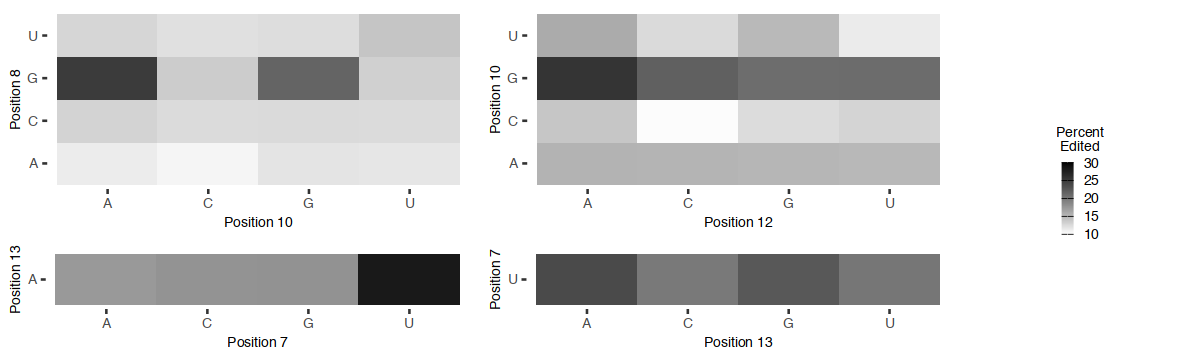

In [ ]:
mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="7_10",tada_type=="lambdaN",tada_conc=="250nM")%>%
    group_by(boxb_10_rc,boxb_8_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    write_tsv("../tables/fig_3c_upper_data.tsv")

mean_editing_per_loop_variant %>%
    filter(boxb_8=="C"&boxb_9=="T"&boxb_10%in% c("T","C"),variable_subpos=="7_10",tada_type=="lambdaN",tada_conc=="250nM")%>% 
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
     write_tsv("../tables/fig_3c_lower_data.tsv")

mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="10_13",tada_type=="lambdaN",tada_conc=="250nM")%>% 
    group_by(boxb_10_rc,boxb_12_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
        write_tsv("../tables/fig_3d_upper_data.tsv")

mean_editing_per_loop_variant %>%
    filter(boxb_10  %in% c("T","C"),boxb_12=="T",variable_subpos=="10_13",tada_type=="lambdaN",tada_conc=="250nM")%>% 
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    write_tsv("../tables/fig_3d_lower_data.tsv")

figure_3c_upperpanel<-mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="7_10",tada_type=="lambdaN",tada_conc=="250nM")%>%
    group_by(boxb_10_rc,boxb_8_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_10_rc,y=boxb_8_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent\nEdited",
            low = "white", high = "black",
            limits = c(10, 30),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8,hjust=0.5),
        legend.text = element_text(size = 8),
        legend.position = "none"
        )+
        labs(y = "Position 8", x = "Position 10",
         )

# ggsave("../figures/heatmaps_8_10.pdf",height = 1.5,width = 2.5)  
figure_3c_lowerpanel <- mean_editing_per_loop_variant %>%
    filter(boxb_8=="C"&boxb_9=="T"&boxb_10%in% c("T","C"),variable_subpos=="7_10",tada_type=="lambdaN",tada_conc=="250nM")%>% 
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_7_rc,y=boxb_13_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(0, 30),
            guide = FALSE)+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8)
        )+
        labs(x = "Position 7", y = "Position 13",
         )

figure_3d_upperpanel<-mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="10_13",tada_type=="lambdaN",tada_conc=="250nM")%>% 
    group_by(boxb_10_rc,boxb_12_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_12_rc,y=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent\nEdited",
            low = "white", high = "black",
            limits = c(10, 30),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            legend.position = "none"
            )+
        labs(x = "Position 12", y = "Position 10",
         )

figure_3d_lowerpanel <- mean_editing_per_loop_variant %>%
    filter(boxb_10  %in% c("T","C"),boxb_12=="T",variable_subpos=="10_13",tada_type=="lambdaN",tada_conc=="250nM")%>% 
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    ggplot(aes(x=boxb_13_rc,y=boxb_7_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent\nEdited",
            low = "white", high = "black",
            limits = c(0, 30),
            guide = FALSE)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8)
            )+
        labs(x = "Position 13", y = "Position 7",
         )

# ggsave("../figures/heatmaps_12_10.pdf",height = 1.5,width = 2.5)


shared_legend <- get_legend(
  figure_3c_upperpanel + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

top_row <- plot_grid(
  figure_3c_upperpanel, figure_3d_upperpanel,
  ncol = 2
)

bottom_row <- plot_grid(
  figure_3c_lowerpanel, figure_3d_lowerpanel,
  ncol = 2
)

# Stack them with different relative heights
plots3c_3d <- plot_grid(
  top_row, bottom_row,
  ncol = 1,
  rel_heights = c(1, 0.5)
)

# Add shared legend
final_plot <- plot_grid(
  plots3c_3d, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(final_plot)

ggsave("../figures/figure_3c_3d.pdf", height=1.6, width=2.5)

### 3I and 3J

In [20]:
figure_3j <- mean_editing_per_stem_variant %>%   
    filter(tada_type=="lambdaN",tada_conc=="250nM")%>%
    ggplot(aes(x=as_factor(energy_bins),y=mean_fraction_edited*100,fill=factor(condition,levels=c("37_30min","37_1hr","37_2hr"))))+
    geom_boxplot(width = 0.6,  color = "black", outlier.shape = NA )+
    theme_classic()+
    scale_y_continuous(limits=c(0,48))+
    scale_x_discrete(labels=c("0-20% \n -14.5-8.6","21-40% \n -8.7-6.0","41-60% \n -6.1-5.2","61-80% \n -5.3-3.4","81-100% \n -3.3-0.3"))+
    scale_fill_manual(values=cbPalette,labels=c("30 min","1 hr","2 hr"))+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      legend.position = "none"
    )+
        labs(x = "Free Energy Percentile\n(Interval in kJ/mol)", y = "Percent Edited",fill="Timepoint"
         )+
    stat_compare_means(
        method = "wilcox.test",      
        label = "p.signif",           
        comparisons = list(c("1","2"),c("2","3"),c("3","4"),c("4","5")),
        label.y = c(45, 40, 35, 30),
        size=3)

# ggsave("../figures/stem_stability.pdf",height = 2.5,width = 4.5) 

figure_3i <- mean_editing_per_stem_variant %>%
    filter(condition=="37_2hr",tada_type=="lambdaN")%>%
    ggplot(aes(x=free_energy))+
    geom_histogram(fill = "gray70", color = "white")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      legend.position = "none"
    )+
    labs(x = "G (kJ/mol, RNAFold)", y = "# BoxB Variants"
         )

# ggsave("../figures/free_energy_histogram.pdf",height = 1.5,width = 3.8) 

figure_3i_3j<-plot_grid(figure_3i,figure_3j,ncol=1,rel_heights = c(1.25, 2))

ggsave("../figures/figure_3i_3j.pdf",height = 3.25,width = 2.25) 

[1] FALSE


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


## Figure 4

### 4C

In [62]:
  figure_4c<-mean_editing_per_recruitment_type  %>%
  ggplot(aes(x = factor(tada_type,levels=enzyme_order), y = mean*100, color=factor(data_type,levels=c("target","boxb")))) +  
  geom_point(size=1) +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=facet_labels)+
  scale_y_continuous(limits = c(0, 75)) +
  scale_color_discrete(labels=c("Recorder","boxB Loop"))+
      theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.text.x = element_text(hjust = 1),
      axis.line = element_line(color = "grey"),
      legend.position= "none"
    )+
    labs(x = "TadA Fusion (250 nM)", y = "Percent Edited",color="Edited Region")

ggsave("../figures/total_edits_types.pdf",height = 1.75,width = 1.5)

### 4D

In [58]:
figure_4d<-editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",tada_type %in% c("gfpnb","pAG"))%>%
    ggplot(aes(x=gnra,y=fraction_edited*100,fill=gnra))+
        facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        geom_point(color="grey50")+
        geom_violin(alpha=0.3)+
        geom_boxplot(width = 0.2, fill = "white", alpha=0.3, color = "black", outlier.shape = NA) +
        theme_classic()+
        scale_fill_manual(values=cbPalette,guide="none")+
        labs(x = "boxB Loop Sequence", y = "Mean Percent Edited",
         )+
        scale_x_discrete(labels=c("Not \n GNRNA","GNRNA"))+
        scale_y_continuous(limits=c(0,60))+
        stat_compare_means(
            method = "wilcox.test",      
            label = "p.format",           
            comparisons = list(c("TRUE", "FALSE")),
            label.y = 55,
            size=3)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_line(color = "grey"),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            strip.background = element_blank()
            )

ggsave("../figures/gnra_recruitment_strategies.pdf",height = 2.10,width = 2.10) 

[1] FALSE


### 4E

`summarise()` has grouped output by 'boxb_8_rc', 'boxb_10_rc'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'boxb_13_rc', 'boxb_7_rc'. You can override
using the `.groups` argument.


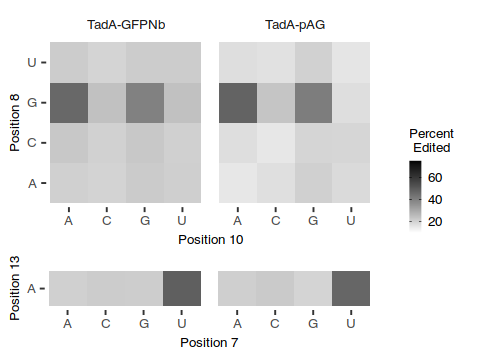

In [ ]:
enzyme_order=c("lambdaN","gfpnb","pAG")
facet_labels <- c("TadA-N","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order

figure_4e_1<-mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="7_10",tada_type %in% c("gfpnb","pAG"))%>% 
    #7-13 base pair is v important for binding and disruption overpowers gnra 
    group_by(boxb_8_rc,boxb_10_rc,tada_type)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    ggplot(aes(y=boxb_8_rc,x=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        scale_fill_gradient(
            name="Percent\n Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        strip.text.x = element_text(size = 8),
        legend.position = "none"
        )+
        labs(y = "Position 8", x = "Position 10",
         )
 

figure_4e_3<-mean_editing_per_loop_variant %>%
    filter(boxb_8=="C"&boxb_9=="T"&boxb_10%in% c("T","C"),variable_subpos=="7_10",tada_type %in% c("gfpnb","pAG"))%>% 
    group_by(boxb_13_rc,boxb_7_rc,tada_type)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_7_rc,y=boxb_13_rc,fill=mean_percent))+
        facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = FALSE)+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        strip.text.x=element_blank()
        )+
        labs(x = "Position 7", y = "Position 13"
         )


shared_legend <- get_legend(
  figure_4e_1 + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

# top_row <- plot_grid(
#   figure_4e_1,figure_4e_2,
#   ncol = 2
# )

# bottom_row <- plot_grid(
#   figure_4e_3,figure_4e_4,
#   ncol = 2
# )

# Stack them with different relative heights
plots_4e <- plot_grid(
  figure_4e_1,figure_4e_3,
  ncol = 1,
  rel_heights = c(1, 0.4)
)

# Add shared legend
figure_4e <- plot_grid(
  plots_4e, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(figure_4e)

ggsave("../figures/recruitment_heatmaps_8_10.pdf",height = 2,width = 2.5) 

### 4F

In [60]:
enzyme_order=c("lambdaN","gfpnb","pAG")
facet_labels <- c("TadA-N","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order
   
figure_4f<-mean_editing_per_stem_variant %>%   
    filter(tada_type %in% c("gfpnb","pAG"))%>%
    ggplot(aes(x=as_factor(energy_bins),y=mean_fraction_edited*100,fill=as_factor(energy_bins)))+
    facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
    geom_boxplot(width = 0.6,  color = "black", outlier.shape = NA )+
    theme_classic()+
    scale_x_discrete(labels=c("0-20%","21-40%","41-60%","61-80%","81-100%"))+
    scale_fill_manual(values=cbPalette,guide=FALSE)+
    scale_y_continuous(limits=c(0,80))+
    theme(
      plot.title = element_text(size = 8, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )+
    stat_compare_means(
        method = "wilcox.test",      
        label = "p.signif",           
        comparisons = list(c("1","2"),c("2","3"),c("3","4"),c("4","5")),
        label.y = c(75, 70, 65, 60),
        size=3)+
        labs(x = "Free Energy Percentile", y = "Percent Edited"
         )

ggsave("../figures/recruitment_stem_stability.pdf",height = 2.10,width = 2.60)  

[1] FALSE


## Supplemental Figure 1

### S1A

In [81]:
position_labs=c("7"="UAG",
"6"="GAA",
"5"="AAU",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU",
"1"= "UAA",
"0"= "AAU"
)
position_order=c("7","6","5","4","3","2","1","0")

sup_figure_1a <- individual_a_editing_context_constant  %>%
  filter(tada_type=="lambdaN") %>%
  ggplot(aes(x = factor(position,level=position_order), y = mean*100,color=tada_conc)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=position_labs)+
  # scale_y_continuous(limits = c(0, 25)) +
  # scale_color_brewer(palette = "RdBu",direction= -1)+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8, hjust=0.5),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "Recorder Position Context", y = "Percent Edited",color="Enzyme \n Concentration")

ggsave("../figures/context_constant_concentrations.pdf",height = 1.5,width = 3.5)

### S1B

In [78]:
supplementary_fig_1b <- mean_edits_single_flanking_context_variable %>%
    ggplot(aes(y=fiveprime,x=threeprime,fill=mean*100))+
    facet_wrap(~factor(position,level=position_order_single_flank),labeller=as_labeller(position_labs_single_flank),nrow=1)+
    geom_tile()+
    scale_fill_gradient(
        name="Percent \n Edited",
        low = "grey93", high = "black",
        limits = c(0, 30),
        guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
    theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        strip.text.x=element_text(size=8)
        )+
        labs(y = "5' Base", x = "3' Base"
         )

ggsave("../figures/context_variable_other_positions.pdf",height = 1.2,width = 3.5)

### Construct S1A and B together

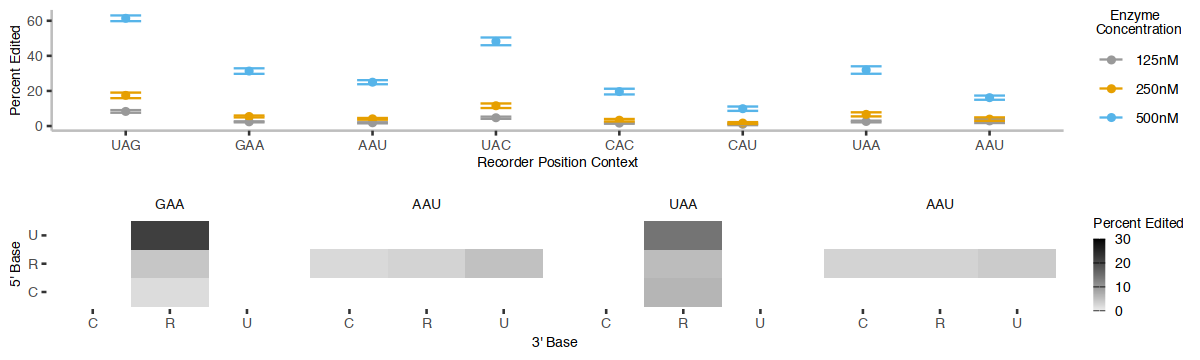

In [26]:
plot_grid(sup_figure_1a,supplementary_fig_1b,ncol=1)

ggsave("../figures/sup_fig_1a_1b.pdf",height = 3,width = 4)

## Supplementary Figure 2

### 2A

`summarise()` has grouped output by 'boxb_10_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_10_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_7_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_7_rc'. You can override using the
`.groups` argument.


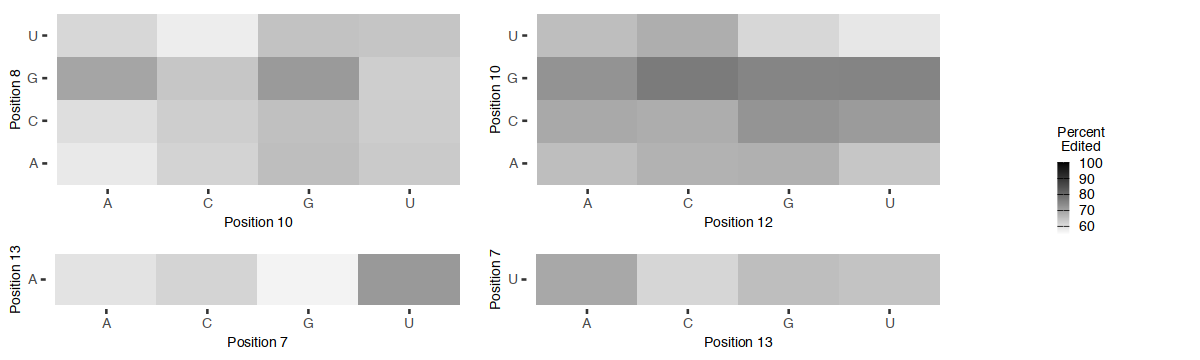

In [57]:
enzyme_order=c("tada_only","lambdaN","gfpnb","pAG")
facet_labels <- c("TadA Alone","TadA-LambdaN","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order

figS2a_top_left<-mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="7_10",tada_conc=="500nM",tada_type=="lambdaN")%>%
    group_by(boxb_10_rc,boxb_8_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_10_rc,y=boxb_8_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent\n Edited",
            low = "white", high = "black",
            limits = c(55, 100),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.position = "none"
        )+
        labs(y = "Position 8", x = "Position 10",
         )

ggsave("../figures/heatmaps_8_10_500nM.pdf",height = 1.5,width = 2.5)  

figS2a_top_right <- mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="10_13",tada_conc=="500nM",tada_type=="lambdaN")%>% 
    group_by(boxb_10_rc,boxb_12_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_12_rc,y=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(55, 100),
            guide = FALSE)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            )+
        labs(x = "Position 12", y = "Position 10",
         )

ggsave("../figures/heatmaps_12_10_500nM.pdf",height = 1.5,width = 2.5) 


figS2a_bottom_left <- mean_editing_per_loop_variant %>%        
    filter(boxb_8=="C"&boxb_9=="T"&boxb_10%in% c("T","C"),variable_subpos=="7_10",tada_conc=="500nM",tada_type=="lambdaN")%>% 
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_7_rc,y=boxb_13_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(55, 100),
            guide = FALSE)+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8)
        )+
        labs(x = "Position 7", y = "Position 13",
         )

ggsave("../figures/heatmaps_7_500nM.pdf",height = 0.75,width = 1.5)  

figS2a_bottom_right<- mean_editing_per_loop_variant  %>%
    filter(boxb_10  %in% c("T","C"),boxb_12=="T",variable_subpos=="10_13",tada_conc=="500nM",tada_type=="lambdaN")%>% 
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    ggplot(aes(x=boxb_13_rc,y=boxb_7_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(55, 100),
            guide = FALSE)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8)
            )+
        labs(x = "Position 13", y = "Position 7",
         )

shared_legend <- get_legend(
  figS2a_top_left + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

# top_row <- plot_grid(
#   figure_4e_1,figure_4e_2,
#   ncol = 2
# )

# bottom_row <- plot_grid(
#   figure_4e_3,figure_4e_4,
#   ncol = 2
# )

# Stack them with different relative heights
plots_S2a <- plot_grid(
  figS2a_top_left,figS2a_top_right,figS2a_bottom_left,figS2a_bottom_right,
  ncol = 2,
  rel_heights = c(1, 0.5)
)

# Add shared legend
figure_S2a <- plot_grid(
  plots_S2a, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(figure_S2a)

ggsave("../figures/figure_S2a.pdf",height=1.6, width=2.5)

### S2B

`summarise()` has grouped output by 'boxb_10_rc'. You can override using the
`.groups` argument.


`summarise()` has grouped output by 'boxb_10_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_7_rc'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'boxb_7_rc'. You can override using the
`.groups` argument.


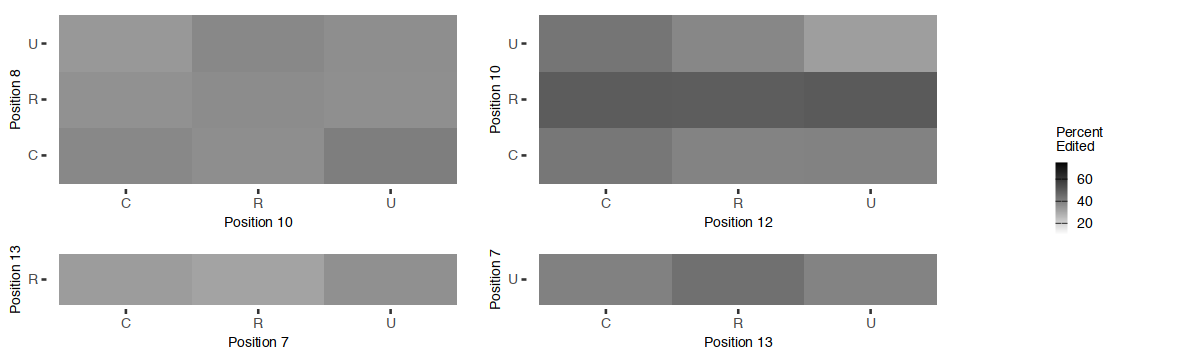

In [56]:
enzyme_order=c("tada_only","lambdaN","gfpnb","pAG")
facet_labels <- c("TadA Alone","TadA-LambdaN","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order

figS2b_1<- mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="7_10",tada_type=="tada_only")%>%
    mutate(boxb_10_rc=case_when(
        boxb_10_rc %in% c("A","G") ~ "R",
        boxb_10_rc =="U" ~ "U",
        boxb_10_rc =="C" ~ "C",
    ),
    boxb_8_rc=case_when(
        boxb_8_rc %in% c("A","G") ~ "R",
        boxb_8_rc =="U" ~ "U",
        boxb_8_rc =="C" ~ "C",
    ))%>%
    group_by(boxb_10_rc,boxb_8_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_10_rc,y=boxb_8_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent \nEdited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.position="none"
        )+
        labs(y = "Position 8", x = "Position 10",
         )

ggsave("../figures/tada_alone_heatmaps_8_10.pdf",height = 1.5,width = 2.5)  

figS2b_2 <- mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="10_13",tada_type=="tada_only")%>% 
        mutate(boxb_10_rc=case_when(
        boxb_10_rc %in% c("A","G") ~ "R",
        boxb_10_rc =="U" ~ "U",
        boxb_10_rc =="C" ~ "C",
    ),
    boxb_12_rc=case_when(
        boxb_12_rc %in% c("A","G") ~ "R",
        boxb_12_rc =="U" ~ "U",
        boxb_12_rc =="C" ~ "C",
    ))%>%
    group_by(boxb_10_rc,boxb_12_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_12_rc,y=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            legend.position="none"
            )+
        labs(x = "Position 12", y = "Position 10",
         )

ggsave("../figures/tada_alone_heatmaps_12_10.pdf",height = 1.5,width = 2.5)  

figS2b_3 <- mean_editing_per_loop_variant %>%
    filter(boxb_8=="C"&boxb_9=="T"&boxb_10%in% c("T","C"),variable_subpos=="7_10",tada_type=="tada_only")%>% 
        mutate(boxb_7_rc=case_when(
        boxb_7_rc %in% c("A","G") ~ "R",
        boxb_7_rc =="U" ~ "U",
        boxb_7_rc =="C" ~ "C",
    ),
    boxb_13_rc=case_when(
        boxb_13_rc %in% c("A","G") ~ "R",
        boxb_13_rc =="U" ~ "U",
        boxb_13_rc =="C" ~ "C",
    ))%>%
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_7_rc,y=boxb_13_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = FALSE)+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8)
        )+
        labs(x = "Position 7", y = "Position 13",
         )

ggsave("../figures/tada_alone_heatmaps_7.pdf",height = 0.75,width = 1.5)  

figS2b_4 <- mean_editing_per_loop_variant %>%
    filter(boxb_10  %in% c("T","C"),boxb_12=="T",variable_subpos=="10_13",tada_type=="tada_only")%>% 
    mutate(boxb_7_rc=case_when(
        boxb_7_rc %in% c("A","G") ~ "R",
        boxb_7_rc =="U" ~ "U",
        boxb_7_rc =="C" ~ "C",
    ),
        boxb_13_rc=case_when(
        boxb_13_rc %in% c("A","G") ~ "R",
        boxb_13_rc =="U" ~ "U",
        boxb_13_rc =="C" ~ "C",
    ))%>%
    group_by(boxb_7_rc,boxb_13_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_13_rc,y=boxb_7_rc,fill=mean_percent))+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = FALSE)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8)
            )+
        labs(x = "Position 13", y = "Position 7",
         )

ggsave("../figures/tada_alone_heatmaps_13.pdf",height = 0.75,width = 1.5)  

shared_legend <- get_legend(
  figS2b_1 + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

# top_row <- plot_grid(
#   figure_4e_1,figure_4e_2,
#   ncol = 2
# )

# bottom_row <- plot_grid(
#   figure_4e_3,figure_4e_4,
#   ncol = 2
# )

# Stack them with different relative heights
plots_S2b <- plot_grid(
  figS2b_1,figS2b_2,figS2b_3,figS2b_4,
  ncol = 2,
  rel_heights = c(1, 0.5)
)

# Add shared legend
figure_S2b <- plot_grid(
  plots_S2b, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(figure_S2b)

ggsave("../figures/figure_S2b.pdf",height=1.6, width=2.5)

### S2C and D

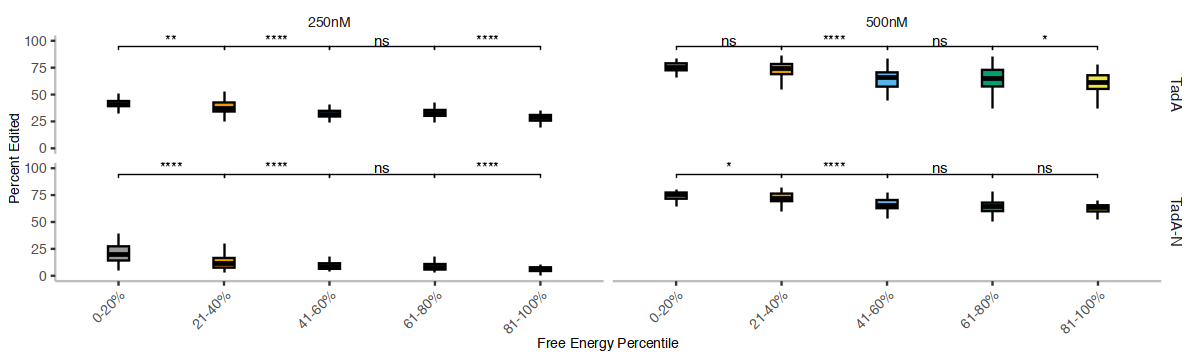

In [72]:
enzyme_order=c("tada_only","lambdaN","gfpnb","pAG")
facet_labels <- c("TadA","TadA-N","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order

mean_editing_per_stem_variant %>%   
    filter(tada_type %in% c("tada_only","lambdaN"),tada_conc %in% c("250nM","500nM"))%>%
    mutate(tada_type_fct = factor(tada_type, levels = enzyme_order)) %>%
    ggplot(aes(x=as_factor(energy_bins),y=mean_fraction_edited*100,fill=as_factor(energy_bins)))+
    facet_grid(rows = vars(tada_type_fct), 
           cols = vars(tada_conc),
           labeller = labeller(tada_type_fct = as_labeller(facet_labels)))+
    geom_boxplot(width = 0.2,  color = "black", outlier.shape = NA )+
    theme_classic()+
    scale_x_discrete(labels=c("0-20%","21-40%","41-60%","61-80%","81-100%"))+
    scale_fill_manual(values=cbPalette,guide=FALSE)+
    scale_y_continuous(limits=c(0,100))+
    theme(
      plot.title = element_text(size = 8, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )+
    stat_compare_means(
        method = "wilcox.test",      
        label = "p.signif",           
        comparisons = list(c("1","2"),c("2","3"),c("3","4"),c("4","5")),
        label.y = c(90, 90, 90, 90),
        size=3)+
        labs(x = "Free Energy Percentile", y = "Percent Edited"
         )

ggsave("../figures/figS2_c_d.pdf",height = 3,width = 3)  

## Supplementary Figure 3

### S3B

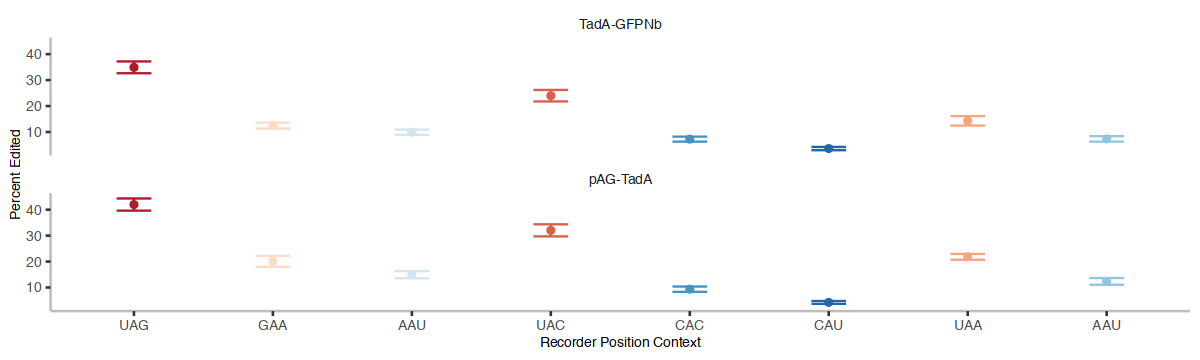

In [77]:
position_labs=c("7"="UAG",
"6"="GAA",
"5"="AAU",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU",
"1"= "UAA",
"0"= "AAU"
)
position_order=c("7","6","5","4","3","2","1","0")
enzyme_order=c("lambdaN","gfpnb","pAG")
facet_labels <- c("N-TadA","TadA-GFPNb","pAG-TadA")
names(facet_labels)<-enzyme_order

individual_a_editing_context_constant  %>%
  filter(tada_type %in% c("gfpnb","pAG"))%>%
  ggplot(aes(x = factor(position,level=position_order), y = mean*100,color=as_factor(scaled_mean))) +  
  facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),ncol=1)+
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=position_labs)+
  # scale_y_continuous(limits = c(0, 7)) +
  scale_color_brewer(palette = "RdBu",direction= -1)+
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      strip.text.x= element_text(size = 8)
    )+
    labs(x = "Recorder Position Context", y = "Percent Edited")

ggsave("../figures/context_constant_recruitments.pdf",height = 2.25,width = 3.25)

### S3C

`summarise()` has grouped output by 'boxb_12_rc', 'boxb_10_rc'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'boxb_13_rc', 'boxb_7_rc'. You can override
using the `.groups` argument.


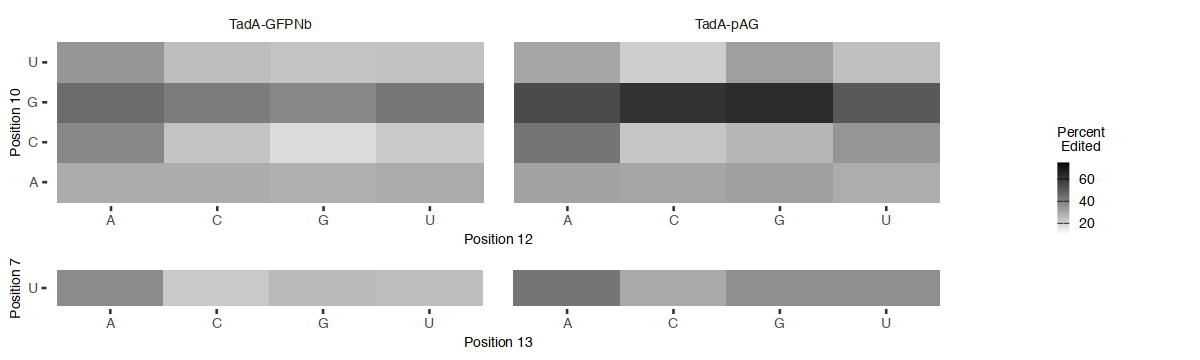

In [75]:
enzyme_order=c("lambdaN","gfpnb","pAG")
facet_labels <- c("TadA-N","TadA-GFPNb","TadA-pAG")
names(facet_labels)<-enzyme_order
 
figure_4e_2<-mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="10_13",tada_type %in% c("gfpnb","pAG"))%>% 
    group_by(boxb_12_rc,boxb_10_rc,tada_type)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_12_rc,y=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        scale_fill_gradient(
            name="Percent\n Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        strip.text.x = element_text(size =8),
        legend.position = "none"
        )+
        labs(x = "Position 12", y = "Position 10",
         )

figure_4e_4<-mean_editing_per_loop_variant %>%
    filter(boxb_10  %in% c("T","C"),boxb_12=="T",variable_subpos=="10_13",tada_type %in% c("gfpnb","pAG"))%>% 
    group_by(boxb_13_rc,boxb_7_rc,tada_type)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_13_rc,y=boxb_7_rc,fill=mean_percent))+
        facet_wrap(~factor(tada_type,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        geom_tile()+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(10, 75),
            guide = FALSE)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            strip.text.x=element_blank()
            )+
        labs(x = "Position 13", y = "Position 7"
         )

shared_legend <- get_legend(
  figure_4e_2 + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

# top_row <- plot_grid(
#   figure_4e_1,figure_4e_2,
#   ncol = 2
# )

# bottom_row <- plot_grid(
#   figure_4e_3,figure_4e_4,
#   ncol = 2
# )

# Stack them with different relative heights
plots_S3c <- plot_grid(
  figure_4e_2,figure_4e_4,
  ncol = 1,
  rel_heights = c(1, 0.4)
)

# Add shared legend
figure_S3c <- plot_grid(
  plots_S3c, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(figure_S3c)

ggsave("../figures/figure_S3_c.pdf",height = 2,width = 2.5) 

### S3E

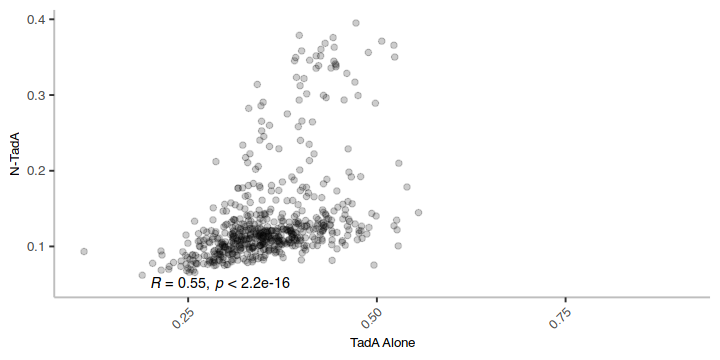

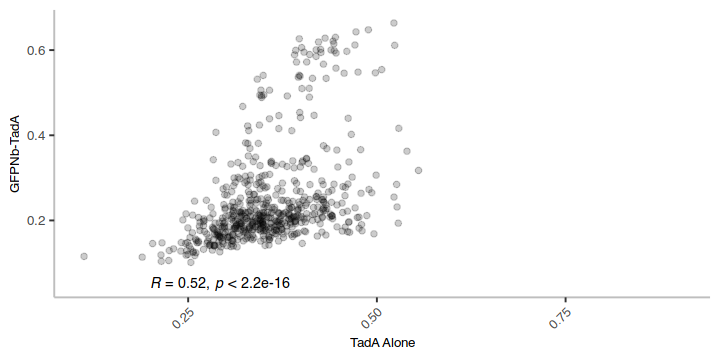

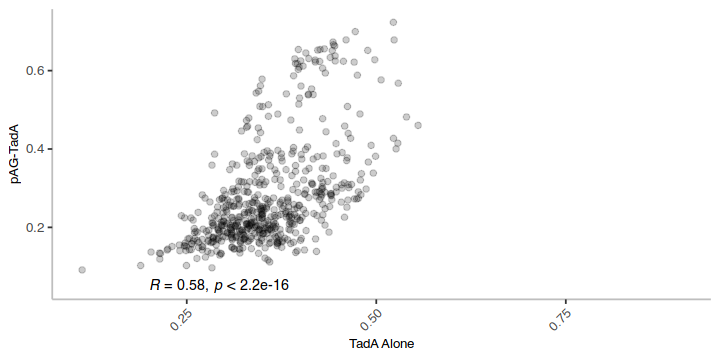

In [33]:
mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p8,y=i79_p3))+
    geom_point(alpha=0.2)+
    stat_cor(method = "spearman",label.x=0.2,label.y=0.05,size=3)+
        labs(x = "TadA Alone", y = "N-TadA"
         )+
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )

ggsave("../figures/tada_vs_ln_tada.pdf",height = 2,width = 2)  

mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p8,y=i79_p20))+
    geom_point(alpha=0.2)+
    stat_cor(method = "spearman",label.x=0.2,label.y=0.05,size=3)+
        labs(x = "TadA Alone", y = "GFPNb-TadA"
         )+
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )

ggsave("../figures/tada_vs_gfpnb_tada.pdf",height = 2,width = 2)  

mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p8,y=i79_p10))+
    geom_point(alpha=0.2)+
    theme_classic()+
    stat_cor(method = "spearman",label.x=0.2,label.y=0.05,size=3)+
        labs(x = "TadA Alone", y = "pAG-TadA"
         )+
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )

ggsave("../figures/tada_vs_pAG_tada.pdf",height = 2,width = 2) 

### S3D

In [ ]:
# moved to supplement
mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p3,y=i79_p20))+
    geom_point(alpha=0.2)+
    stat_cor(method = "spearman",label.x=0.10,label.y=0.05,size=3)+
        labs(x = "Lambda-N TadA", y = "GFPNb-TadA"
         )+
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )

ggsave("../figures/ln_v_gfpnb.pdf",height = 2,width = 2)  

mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p3,y=i79_p10))+
    geom_point(alpha=0.2)+
    theme_classic()+
    stat_cor(method = "spearman",label.x=0.10,label.y=0.05,size=3)+
        labs(x = "Lambda-N TadA", y = "pAG-TadA"
         )+
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )

ggsave("../figures/ln_v_pAG.pdf",height = 2,width = 2)  